# CNN-LSTM — COVID Fake News Detection (DS 340W)

**Changes from v1** (v1 got stuck predicting "real" for every tweet, ~52% accuracy):
1. **`padding="pre"` and `MAX_LENGTH = 64`.** With post-padding to 128, every tweet (avg ~27 tokens) ended in ~100 zeros, so the LSTM's final state was nearly identical for every input and the model collapsed to the class prior.
2. **Early stopping and checkpointing watch `val_loss`** with `patience=3`, and `epochs=20`. With `patience=2` on F1, v1 stopped one epoch before the model started learning.
3. **The F1 callback uses macro F1.** Binary F1 on class 1 (real) gave 0.687 to a model predicting "real" for everything, which hid the collapse.
4. **Fixed random seed**, a **test-set evaluation** section, and a **multi-seed run** (mean ± std) for the report.

Label mapping: **fake = 0, real = 1**. Keep this the same in every notebook.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

folder_path = "/content/drive/My Drive/DS 340W/"

train_df = pd.read_csv(folder_path + "train.csv")
validation_df = pd.read_csv(folder_path + "validation.csv")
test_df = pd.read_csv(folder_path + "test.csv")

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(validation_df["label"].value_counts())

print("\nTesting labels:")
print(test_df["label"].value_counts())

Training: 4494
Validation: 642
Testing: 1284

Training labels:
label
real    2352
fake    2142
Name: count, dtype: int64

Validation labels:
label
real    336
fake    306
Name: count, dtype: int64

Testing labels:
label
real    672
fake    612
Name: count, dtype: int64


In [3]:
# Convert labels to integers
# fake = 0
# real = 1

label_map = {
    "fake": 0,
    "real": 1
}

train_df["label"] = train_df["label"].map(label_map)
validation_df["label"] = validation_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# Extract tweets and labels
train_texts = train_df["tweet"].astype(str).tolist()
train_labels = train_df["label"].tolist()

validation_texts = validation_df["tweet"].astype(str).tolist()
validation_labels = validation_df["label"].tolist()

test_texts = test_df["tweet"].astype(str).tolist()
test_labels = test_df["label"].tolist()

print("Example tweet:")
print(train_texts[0])

print("\nExample label:")
print(train_labels[0])

print("\nUnique labels:")
print(sorted(set(train_labels)))

Example tweet:
The novel coronavirus can be cured by one bowl of freshly boiled garlic.

Example label:
0

Unique labels:
[0, 1]


In [4]:
!pip install -q tensorflow scikit-learn pandas matplotlib seaborn

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

# Reproducibility: fixes Python, NumPy and TensorFlow seeds
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.20.0


## Tokenize and pad
Pre-padding puts the zeros *before* the tweet, so the LSTM reads the real words last.

In [6]:
MAX_WORDS = 20000
MAX_LENGTH = 64   # covers ~95% of tweets (avg ~27 words)

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# Learn vocabulary from training data only
tokenizer.fit_on_texts(train_texts)

# Convert text to integer sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Pad sequences to the same length
X_train = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="post"
)

X_validation = pad_sequences(
    validation_sequences,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="post"
)

y_train = np.array(train_labels)
y_validation = np.array(validation_labels)
y_test = np.array(test_labels)

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)
print("X_test shape:", X_test.shape)

print("Vocabulary size:", len(tokenizer.word_index))

print("Avg non-padding tokens per tweet:", (X_train != 0).sum(axis=1).mean().round(1))

X_train shape: (4494, 64)
X_validation shape: (642, 64)
X_test shape: (1284, 64)
Vocabulary size: 15733
Avg non-padding tokens per tweet: 29.6


## Model
Wrapped in a function so the multi-seed section at the end can rebuild a fresh model.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dropout,
    Dense
)

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

def build_model():
    model = Sequential([
        Input(shape=(MAX_LENGTH,)),

        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128
        ),

        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(
            pool_size=2
        ),

        LSTM(
            64
        ),

        Dropout(0.3),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.3),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 128)        │     2,013,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 62, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,865 (8.08 MB)

 Trainable params: 2,116,865 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

## Callbacks

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = "/content/drive/MyDrive/cnn_lstm_best.keras"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


In [9]:
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

class ValidationF1Callback(Callback):
    """Prints macro F1 on the validation set after each epoch (for monitoring only)."""
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        X_val, y_val = self.validation_data

        predictions = self.model.predict(X_val, verbose=0)
        predicted_labels = (predictions >= 0.5).astype(int).flatten()

        # Macro F1 treats fake and real equally, so a model that predicts
        # one class for everything can't hide behind a decent-looking score
        val_f1 = f1_score(
            y_val,
            predicted_labels,
            average="macro",
            zero_division=0
        )

        logs["val_f1"] = val_f1
        print(f" — val_macro_f1: {val_f1:.4f}")

In [10]:
validation_f1 = ValidationF1Callback(
    validation_data=(X_validation, y_validation)
)

print("Validation F1 callback ready!")

Validation F1 callback ready!


## Train

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=20,
    batch_size=32,
    callbacks=[
        validation_f1,
        checkpoint,
        early_stopping
    ],
    verbose=1
)

Epoch 1/20
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7506 - loss: 0.4900 — val_macro_f1: 0.9050

Epoch 1: val_loss improved from None to 0.21628, saving model to /content/drive/MyDrive/cnn_lstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_lstm_best.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.8385 - loss: 0.3501 - val_accuracy: 0.9050 - val_loss: 0.2163 - val_f1: 0.9050
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9485 - loss: 0.1329 — val_macro_f1: 0.9314

Epoch 2: val_loss did not improve from 0.21628
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9711 - loss: 0.0755 - val_accuracy: 0.9315 - val_loss: 0.2499 - val_f1: 0.9314
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9959 - loss: 0.0207 — val_macro_f1: 0.9217

Epoch 3: val_loss did not improve from 0.21628
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.9989 - loss: 0.0077 - val_accuracy: 0.9221 - val_loss: 0.3

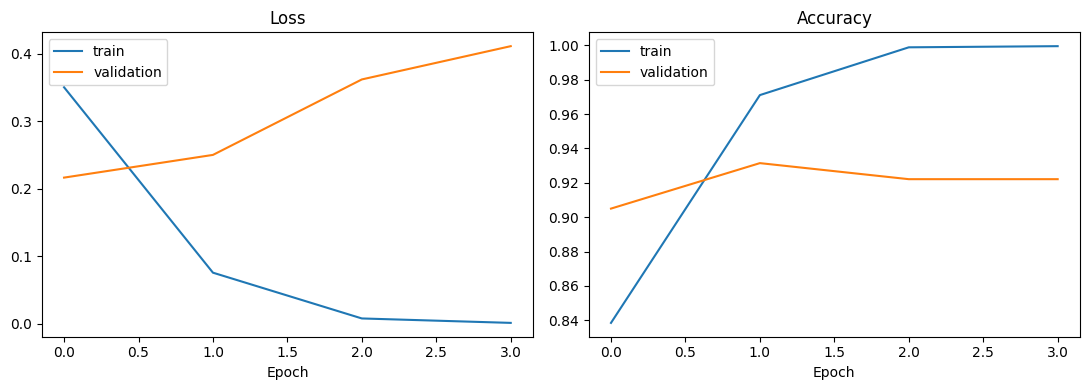

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## Sanity check: is the model predicting both classes?
In v1 every probability was ~0.529. Now they should spread toward 0 and 1.

In [13]:
# Check what the model is predicting on the validation set

val_probabilities = model.predict(
    X_validation,
    verbose=0
).flatten()

val_predictions = (val_probabilities >= 0.5).astype(int)

print("Predicted class counts:")
print(pd.Series(val_predictions).value_counts().sort_index())

print("\nActual class counts:")
print(pd.Series(y_validation).value_counts().sort_index())

print("\nPrediction probability summary:")
print("Minimum:", val_probabilities.min())
print("Maximum:", val_probabilities.max())
print("Mean:", val_probabilities.mean())

Predicted class counts:
0    339
1    303
Name: count, dtype: int64

Actual class counts:
0    306
1    336
Name: count, dtype: int64

Prediction probability summary:
Minimum: 0.002810485
Maximum: 0.9985191
Mean: 0.48925635


## Test-set evaluation
Run once, after all tuning is done on the validation set.

Accuracy:         0.9151
Precision (real): 0.9577
Recall (real):    0.8765
F1 (real):        0.9153
Macro F1:         0.9151

Classification report:
              precision    recall  f1-score   support

        fake     0.8759    0.9575    0.9149       612
        real     0.9577    0.8765    0.9153       672

    accuracy                         0.9151      1284
   macro avg     0.9168    0.9170    0.9151      1284
weighted avg     0.9187    0.9151    0.9151      1284



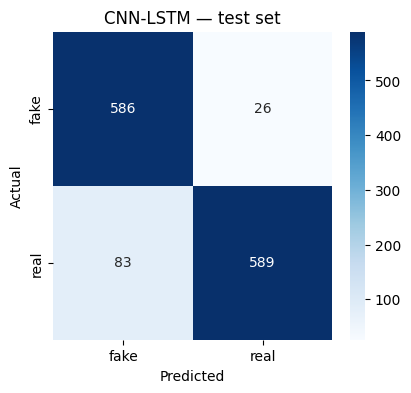

In [14]:
import seaborn as sns

test_probabilities = model.predict(X_test, verbose=0).flatten()
test_predictions = (test_probabilities >= 0.5).astype(int)

print("Accuracy:        ", round(accuracy_score(y_test, test_predictions), 4))
print("Precision (real):", round(precision_score(y_test, test_predictions), 4))
print("Recall (real):   ", round(recall_score(y_test, test_predictions), 4))
print("F1 (real):       ", round(f1_score(y_test, test_predictions), 4))
print("Macro F1:        ", round(f1_score(y_test, test_predictions, average="macro"), 4))

print("\nClassification report:")
print(classification_report(y_test, test_predictions, target_names=["fake", "real"], digits=4))

cm = confusion_matrix(y_test, test_predictions)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["fake", "real"], yticklabels=["fake", "real"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("CNN-LSTM — test set")
plt.show()

## Multi-seed run (for the report)
Deep learning scores on ~4.5k tweets can move ±1% between runs, so report mean ± std over several seeds. Each seed trains a fresh model with fresh callbacks. Takes a few minutes on a Colab GPU.

In [15]:
SEEDS = [0, 1, 2, 3, 42]
results = []

for seed in SEEDS:
    tf.keras.utils.set_random_seed(seed)
    m = build_model()
    es = EarlyStopping(monitor="val_loss", mode="min", patience=3, restore_best_weights=True)
    m.fit(X_train, y_train,
          validation_data=(X_validation, y_validation),
          epochs=20, batch_size=32, callbacks=[es], verbose=0)

    preds = (m.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
    results.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
    })
    print(f"seed {seed}: acc={results[-1]['accuracy']:.4f}  macro_f1={results[-1]['macro_f1']:.4f}")

results_df = pd.DataFrame(results)
summary = results_df.drop(columns="seed").agg(["mean", "std"]).T.round(4)
print("\nMean ± std over", len(SEEDS), "seeds:")
print(summary)

results_df.to_csv(folder_path + "cnn_lstm_seed_results.csv", index=False)

seed 0: acc=0.9120  macro_f1=0.9115
seed 1: acc=0.9104  macro_f1=0.9103
seed 2: acc=0.8956  macro_f1=0.8955
seed 3: acc=0.9268  macro_f1=0.9265
seed 42: acc=0.9151  macro_f1=0.9151

Mean ± std over 5 seeds:
             mean     std
accuracy   0.9120  0.0112
precision  0.9352  0.0311
recall     0.8961  0.0501
f1         0.9138  0.0141
macro_f1   0.9118  0.0111
